# Joined Dataset EDA


### 📋 Methodology Note
**Data Cleaning & Scope**
This exploratory analysis assesses the coverage of the CAT ratings against the full UBCBG IrisBG living collection. Additionally a taxonomic backbone from the World Online Flora was added to discuss some specific challenges of conservation. 
* **Inclusion Criteria:** All taxa that have been historically grown at the current UBC Botanical Garden (1970 -2024), taxa with full genera an specific epithet available in IrisBG and with a corresponding 'valid' status in WFO, taxa that are available in CAT database. Accessions that have a value in the Lifeform field.
* **Exclusion:** Taxa that are cultivars of are missing species information, Nursery and Nitobe material for ease of mapping, Accession whose lifeform is not included in this list:
* woody_list = ['Tree', 'Shrub', 'Shrub or Tree']
* herb_list = ['Herbaceous Perennial', 'Climber_Liana_Vine'].
* **Validation:** Taxa names were cross-referenced against [WFO Taxonomic Backbone] to resolve synonyms.

## 1. Import libraries and datasets

Display a sample of 5 observations (accession items).

In [18]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import matplotlib.gridspec as gridspec

#set matplotlib figure parameters
mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['savefig.dpi'] = 110

# Load the CSV file
# The keys in this file have been corrected to 2050 and 2090
file_path = "../data/FullJoin3_with_climate_ratings-proofed.csv"
df = pd.read_csv(file_path)

# Map the long column names to shorthand versions for easier coding
column_mapping = {
    'climate_rating_current_sheet': 'rating_2025_current',
    'climate_rating_emissions_limited_2050': 'rating_2050_limited',
    'climate_rating_business_as_usual_2090': 'rating_2090_bau',
    'climate_rating_bau_plus_1degree_2090': 'rating_2090_heat_sink'
}
df = df.rename(columns=column_mapping)

# Display first few rows to confirm keys and data structure
display(df.head())

,AccNoFull,ItemAccNoFull,LocationName,LocationCoordY,LocationCoordX,LifeForm,Family,Genus,GenusSpecies,ItemLocationCode,...,ItemType,IUCNRedList,NationalRedList,RegionalRedList,Locality,LocalityFull,rating_2050_limited,rating_2025_current,rating_2090_bau,rating_2090_heat_sink
0,1999-0404,1999-0404.01,Contemporary Garden,-123.246025,49.253365,Shrub,Oleaceae,Abeliophyllum,Abeliophyllum distichum,1C01,...,Planting,NaN,NaN,NaN,NaN,NaN,9.0,11.0,3.0,3.0
1,2014-0168,2014-0168.01,Asian Garden,-123.251150,49.253642,Shrub,Oleaceae,Abeliophyllum,Abeliophyllum distichum,3AAF,...,Planting,NaN,NaN,NaN,NaN,NaN,9.0,11.0,3.0,3.0
2,1983-0427,1983-0427.01,Alpine Garden,-123.246104,49.253650,Shrub,Pinaceae,Abies,Abies koreana,LAS4,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,5.0,5.0
3,1987-0067,1987-0067.01,Alpine Garden,-123.246737,49.254134,Shrub,Pinaceae,Abies,Abies balsamea,LNA3,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,3.0,3.0
4,1987-0067,1987-0067.02,Alpine Garden,-123.246714,49.254241,Shrub,Pinaceae,Abies,Abies balsamea,LNA1,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,3.0,3.0


## 2. CAT Coverage Analysis

Taxa submitted to CAT that were returned without data (NA) in the climate rating field were discarded. 

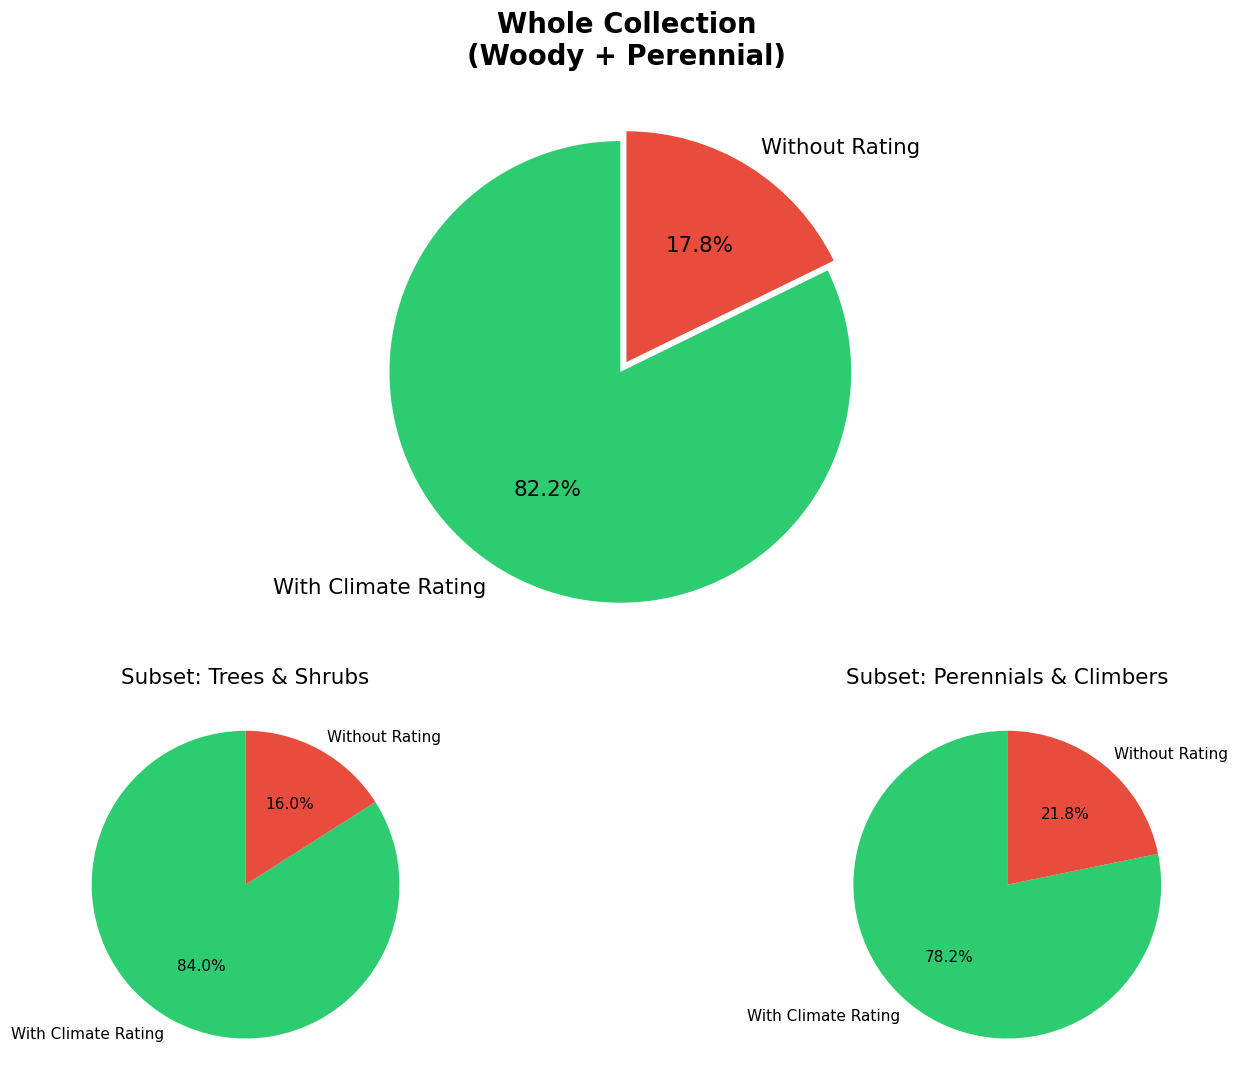

In [19]:

# 1. Filter the dataset for included lifeforms only
included_lifeforms = ['Tree', 'Shrub', 'Shrub or Tree', 'Herbaceous Perennial', 'Climber_Liana_Vine']
df_filtered = df[df['LifeForm'].isin(included_lifeforms)].copy()

# 2. Define our target subsets
tree_shrub_list = ['Tree', 'Shrub', 'Shrub or Tree']
perennial_list = ['Herbaceous Perennial', 'Climber_Liana_Vine']

tree_shrub_df = df_filtered[df_filtered['LifeForm'].isin(tree_shrub_list)]
perennial_df = df_filtered[df_filtered['LifeForm'].isin(perennial_list)]

# 3. Helper function for counts
climate_cols = ['rating_2025_current', 'rating_2050_limited', 'rating_2090_bau', 'rating_2090_heat_sink']

def get_counts(data):
    # Counts how many rows have at least one climate rating
    with_rating = data[climate_cols].notna().any(axis=1).sum()
    return [with_rating, len(data) - with_rating]

# 4. Visualization
labels = ["With Climate Rating", "Without Rating"]
colors = ['#2ecc71', '#e74c3c']

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 1])

# Large Pie: Total Included Collection
ax0 = plt.subplot(gs[0, :])
ax0.pie(get_counts(df_filtered), labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=colors, explode=(0.05, 0), textprops={'fontsize': 14})
ax0.set_title("Whole Collection\n(Woody + Perennial)", fontsize=18, fontweight='bold')

# Small Pie: Woody Subset (Tree/Shrub)
ax1 = plt.subplot(gs[1, 0])
ax1.pie(get_counts(tree_shrub_df), labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title("Subset: Trees & Shrubs", fontsize=14)

# Small Pie: Perennial/Climber Subset
ax2 = plt.subplot(gs[1, 1])
ax2.pie(get_counts(perennial_df), labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title("Subset: Perennials & Climbers", fontsize=14)

plt.tight_layout()
plt.show()


## 3. Climate Rating Trends within the CAT data for UBC
This section identifies the "Mean Drop" in suitability as we move toward the late-century urban heat-sink scenario.

Families experiencing the most significant decline in suitability (2025 vs 2090 Heat Sink):


,rating_2025_current,rating_2090_heat_sink,suitability_drop
Family,,,
Lentibulariaceae,11.00,2.00,9.00
Typhaceae,11.00,2.00,9.00
Juncaceae,10.00,2.50,7.50
Violaceae,10.38,3.31,7.08
Polygalaceae,9.00,2.00,7.00
Tofieldiaceae,9.00,2.00,7.00
Gentianaceae,9.24,2.71,6.53
Linaceae,10.00,3.50,6.50
Montiaceae,9.73,3.67,6.07


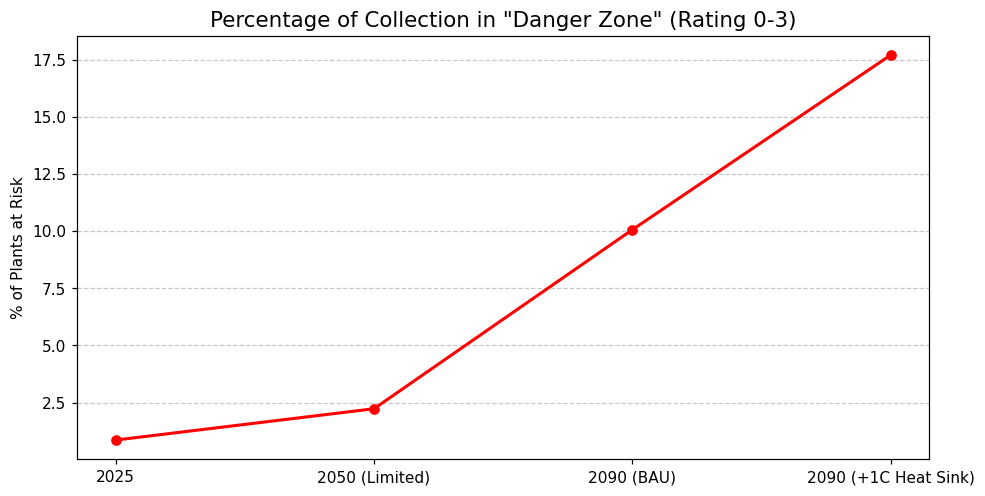

In [5]:
# 1. Calculate Average Ratings per Family for comparison
avg_ratings = df_filtered.groupby('Family')[['rating_2025_current', 'rating_2090_heat_sink']].mean()

# 2. Calculate the 'Suitability Drop'
avg_ratings['suitability_drop'] = avg_ratings['rating_2025_current'] - avg_ratings['rating_2090_heat_sink']

# 3. Apply the 2-decimal rounding rule
avg_ratings = avg_ratings.round(2)

print("Families experiencing the most significant decline in suitability (2025 vs 2090 Heat Sink):")
display(avg_ratings.sort_values('suitability_drop', ascending=False).head(10))

# 4. Calculate overall garden risk percentage across scenarios
scenarios = {
    '2025': 'rating_2025_current',
    '2050 (Limited)': 'rating_2050_limited',
    '2090 (BAU)': 'rating_2090_bau',
    '2090 (+1C Heat Sink)': 'rating_2090_heat_sink'
}

risk_trend = {}
for label, col in scenarios.items():
    pct = (df_filtered[col] <= 3).mean() * 100
    risk_trend[label] = round(pct, 2)

# Visualization of the migration to risk
plt.figure(figsize=(10, 5))
plt.plot(list(risk_trend.keys()), list(risk_trend.values()), marker='o', color='red', linewidth=2)
plt.title('Percentage of Collection in "Danger Zone" (Rating 0-3)', fontsize=14)
plt.ylabel('% of Plants at Risk')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. Conservation Red-Flags (Global Taxonomic Context)
This section uses the WFO backbone to identify families that are evolutionarily unique at a global scale. We then filter these to find those at highest risk in our 2090 Heat Sink model.

In [6]:
# 1. Load the WFO Backbone 
# (Adjusting path to local environment)
wfo_path = '../data/wfo_accepted_species_family_genus_tidy.csv'
wfo_df = pd.read_csv(wfo_path)

# 2. Aggregate WFO to the Family level (Global Stats)
wfo_family_stats = wfo_df.groupby('family').agg({
    'n_genera_in_family': 'first',
    'n_accepted_species_in_family': 'first'
}).reset_index()

wfo_family_stats.columns = ['Family', 'Global_Genus_Count', 'Global_Species_Count']

# 3. Merge with the main garden dataframe (df_filtered from Section 2)
df_taxonomic = pd.merge(df_filtered, wfo_family_stats, on='Family', how='left')

# 4. Calculate Family-level Risk for the 2090 Heat Sink Scenario
# We look for the 'Danger Zone' (Rating <= 3)
risk_col = 'rating_2090_heat_sink'
threshold = 3

# Define the summary to avoid NameErrors
family_conservation_summary = df_taxonomic.dropna(subset=[risk_col]).groupby('Family').agg(
    Garden_Count=('Family', 'count'),
    Mean_Rating_2090=(risk_col, 'mean'),
    At_Risk_Count=(risk_col, lambda x: (x <= threshold).sum()),
    Global_Genera=('Global_Genus_Count', 'first'),
    Global_Species=('Global_Species_Count', 'first')
).reset_index()

# Calculate percentages and round for authenticity
family_conservation_summary['Percent_At_Risk'] = (family_conservation_summary['At_Risk_Count'] / family_conservation_summary['Garden_Count'] * 100).round(2)
family_conservation_summary['Mean_Rating_2090'] = family_conservation_summary['Mean_Rating_2090'].round(2)

# 5. Split and Display Outputs
# Tier 1: Globally Monospecific (1 Genus, 1 Species)
monospecific = family_conservation_summary[
    (family_conservation_summary['Global_Genera'] == 1) & 
    (family_conservation_summary['Global_Species'] == 1)
].sort_values('Mean_Rating_2090')

# Tier 2: Globally Monogeneric (1 Genus, >1 Species)
monogeneric = family_conservation_summary[
    (family_conservation_summary['Global_Genera'] == 1) & 
    (family_conservation_summary['Global_Species'] > 1)
].sort_values('Mean_Rating_2090')

print("--- TIER 1: GLOBALLY MONOSPECIFIC FAMILIES ---")
display(monospecific[['Family', 'Garden_Count', 'Mean_Rating_2090', 'Percent_At_Risk']])

print("\n--- TIER 2: GLOBALLY MONOGENERIC FAMILIES ---")
display(monogeneric[['Family', 'Garden_Count', 'Mean_Rating_2090', 'Percent_At_Risk', 'Global_Species']])

--- TIER 1: GLOBALLY MONOSPECIFIC FAMILIES ---


,Family,Garden_Count,Mean_Rating_2090,Percent_At_Risk
160,Sciadopityaceae,20,5.0,0.0
83,Ginkgoaceae,6,11.0,0.0



--- TIER 2: GLOBALLY MONOGENERIC FAMILIES ---


,Family,Garden_Count,Mean_Rating_2090,Percent_At_Risk,Global_Species
188,Woodsiaceae,3,2.00,100.00,53.0
69,Equisetaceae,6,4.00,66.67,41.0
84,Grossulariaceae,97,4.22,61.86,206.0
117,Nothofagaceae,3,5.00,0.00,44.0
128,Paeoniaceae,62,5.53,19.35,42.0
85,Gunneraceae,3,5.67,0.00,66.0
178,Tropaeolaceae,5,6.00,40.00,97.0
68,Ephedraceae,14,6.64,7.14,74.0
45,Cercidiphyllaceae,29,7.48,10.34,2.0
58,Datiscaceae,1,8.00,0.00,2.0


## 5. Management Priorities (The >20 Rule)
While Section 4 deals with "Evolutionary Gems," Section 5 deals with the "Workhorses" of the garden. These are the families with at least 20 accessions. High risk here indicates a need for significant labor, budget allocation, or a transition to new taxa.

--- MANAGEMENT PRIORITIES: Large-scale Failure Points (>20 members) ---
These groups require systemic adaptation strategies (e.g., site mitigation or species replacement).


,Family,Garden_Count,Mean_Rating_2090,At_Risk_Count,Global_Genera,Global_Species,Percent_At_Risk
112,Montiaceae,30,3.67,22,13.0,251.0,73.33
52,Crassulaceae,142,4.01,98,39.0,1700.0,69.01
84,Grossulariaceae,97,4.22,60,1.0,206.0,61.86
42,Caryophyllaceae,76,3.84,47,107.0,2657.0,61.84
136,Plantaginaceae,192,4.35,114,107.0,2277.0,59.38
107,Melanthiaceae,54,4.50,32,14.0,191.0,59.26
32,Brassicaceae,75,4.05,44,361.0,4388.0,58.67
81,Geraniaceae,57,4.47,30,7.0,819.0,52.63
31,Boraginaceae,43,4.67,22,116.0,2121.0,51.16
38,Campanulaceae,42,4.93,21,89.0,2477.0,50.00


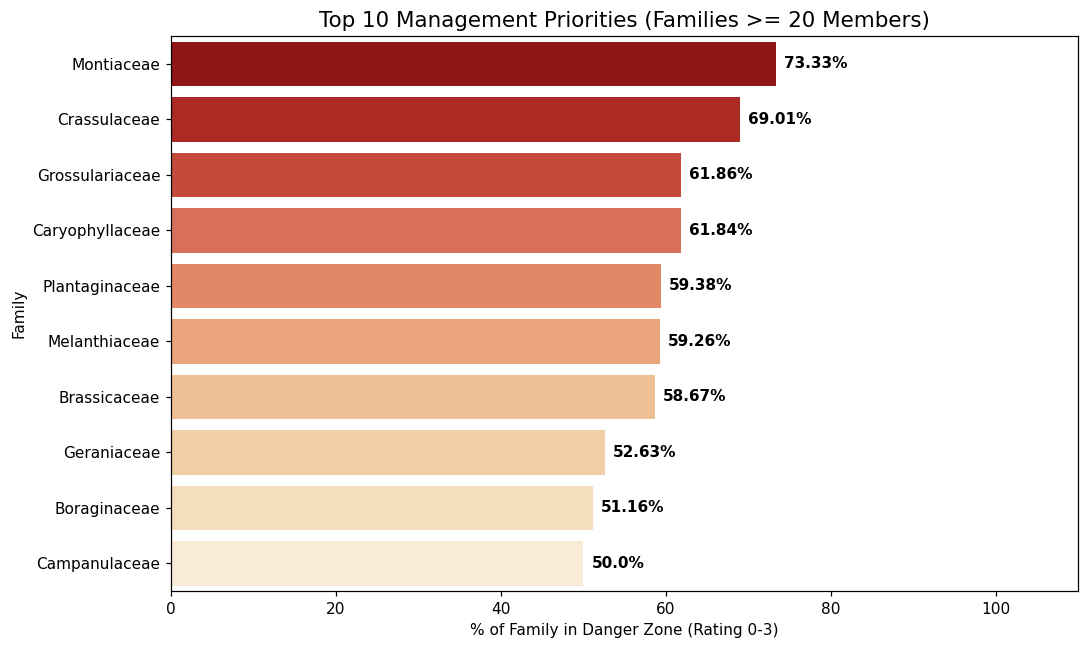

In [7]:

# 1. Filter for families with >= 20 representatives in the garden
# We use the summary dataframe 'family_conservation_summary' defined in Section 4
management_priorities = family_conservation_summary[family_conservation_summary['Garden_Count'] >= 20].copy()

# 2. Sort by highest percentage in the danger zone (Rating 0-3)
management_priorities = management_priorities.sort_values('Percent_At_Risk', ascending=False)

print("--- MANAGEMENT PRIORITIES: Large-scale Failure Points (>20 members) ---")
print("These groups require systemic adaptation strategies (e.g., site mitigation or species replacement).")
display(management_priorities.head(10))

# 3. Visualization: Management Priority Bar Chart
# Fixed the FutureWarning by assigning y to hue and setting legend=False
plt.figure(figsize=(10, 6))
top_management = management_priorities.head(10)

sns.barplot(
    data=top_management, 
    x='Percent_At_Risk', 
    y='Family', 
    hue='Family',      # Fixed: Assigning hue to the y-axis variable
    palette='OrRd_r', 
    legend=False       # Fixed: Hiding the redundant legend
)

plt.title('Top 10 Management Priorities (Families >= 20 Members)', fontsize=14)
plt.xlabel('% of Family in Danger Zone (Rating 0-3)')
plt.ylabel('Family')

# Add percentage labels to the end of the bars for clarity
for i, v in enumerate(top_management['Percent_At_Risk']):
    plt.text(v + 1, i, f"{v}%", va='center', fontweight='bold')

plt.xlim(0, 110) # Leave room for the text labels
plt.tight_layout()
plt.show()

## 6. Climate Heroes (Exceptional Stability in 2090)
In this section, we identify families with high mean suitability ratings ($\ge 9.0$) in the 2090 Heat Sink scenario. We split these into Management Heroes (reliable, high-volume groups) and Evolutionary Heroes (unique lineages that are surprisingly resilient).

--- MANAGEMENT HEROES: Robust Large Groups (>= 20 members) ---


,Family,Garden_Count,Mean_Rating_2090
89,Hydrangeaceae,404,9.35
105,Magnoliaceae,183,9.14
167,Styracaceae,107,9.90
13,Aquifoliaceae,99,9.09
98,Lauraceae,91,9.40
173,Theaceae,87,10.15
86,Hamamelidaceae,65,9.95
130,Paulowniaceae,47,11.00
177,Trochodendraceae,47,11.00
122,Onagraceae,41,9.51



--- EVOLUTIONARY HEROES: Resilient Unique Lineages (Global Monogeneric) ---


,Family,Garden_Count,Global_Species,Mean_Rating_2090
44,Cephalotaxaceae,21,8.0,11.00
77,Frankeniaceae,1,81.0,11.00
83,Ginkgoaceae,6,1.0,11.00
88,Helwingiaceae,8,4.0,11.00
137,Platanaceae,3,11.0,11.00
163,Smilacaceae,2,261.0,11.00
165,Stachyuraceae,14,10.0,11.00
168,Symplocaceae,3,412.0,11.00
6,Altingiaceae,15,15.0,10.87
57,Daphniphyllaceae,6,31.0,10.67


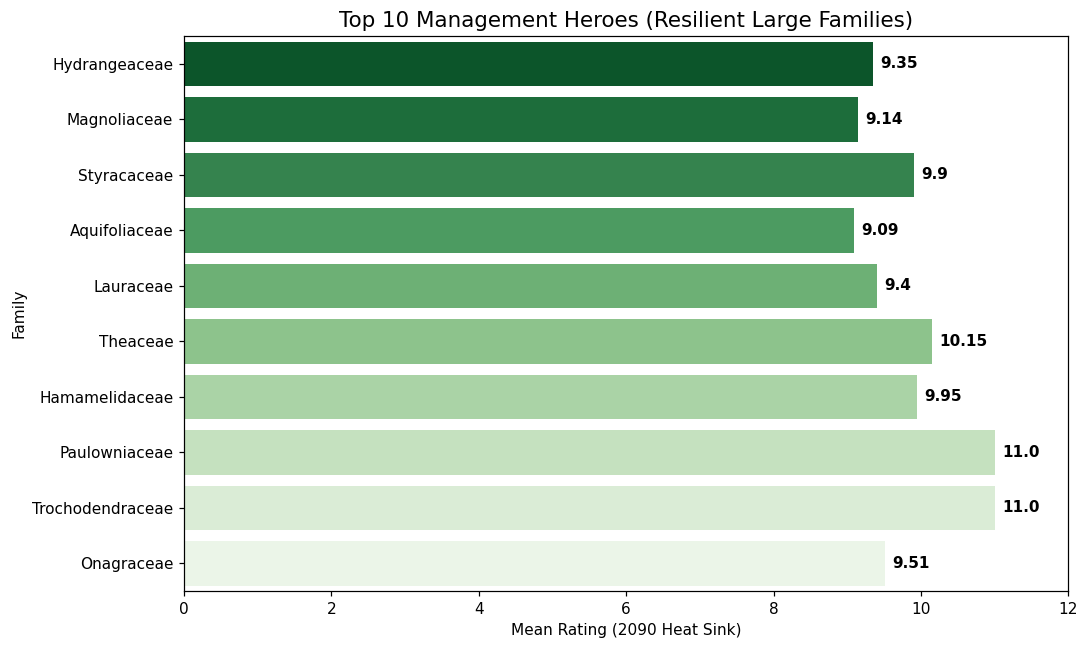

In [8]:
# 1. Define 'Climate Heroes' (Mean Rating >= 9.0 in 2090 Heat Sink)
hero_threshold = 9.0
risk_col = 'rating_2090_heat_sink'

# We use the family-level summary generated in previous steps
family_hero_summary = family_conservation_summary[family_conservation_summary['Mean_Rating_2090'] >= hero_threshold].copy()

# 2. Split into Management and Evolutionary Tiers
# Management Heroes: Families with >= 20 accessions (The Future Backbone)
management_heroes = family_hero_summary[family_hero_summary['Garden_Count'] >= 20].sort_values('Garden_Count', ascending=False)

# Evolutionary Heroes: Globally Monogeneric lineages (Unique but Resilient)
evolutionary_heroes = family_hero_summary[family_hero_summary['Global_Genera'] == 1].sort_values('Mean_Rating_2090', ascending=False)

# 3. Output Table: Management Heroes
print("--- MANAGEMENT HEROES: Robust Large Groups (>= 20 members) ---")
display(management_heroes[['Family', 'Garden_Count', 'Mean_Rating_2090']].head(10))

# 4. Output Table: Evolutionary Heroes
print("\n--- EVOLUTIONARY HEROES: Resilient Unique Lineages (Global Monogeneric) ---")
display(evolutionary_heroes[['Family', 'Garden_Count', 'Global_Species', 'Mean_Rating_2090']])

# 5. Visualization: The Stability of Management Heroes
plt.figure(figsize=(10, 6))
sns.barplot(
    data=management_heroes.head(10), 
    x='Mean_Rating_2090', 
    y='Family', 
    hue='Family',
    palette='Greens_r'
)
plt.title('Top 10 Management Heroes (Resilient Large Families)', fontsize=14)
plt.xlabel('Mean Rating (2090 Heat Sink)')
plt.ylabel('Family')
plt.xlim(0, 12)
plt.legend([],[], frameon=False) # Removes redundant legend

# Add labels to the end of bars
for i, v in enumerate(management_heroes.head(10)['Mean_Rating_2090']):
    plt.text(v + 0.1, i, f"{v}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Spatial Risk Map
By mapping the collection according to its physical coordinates (LocationCoordX, LocationCoordY), we can move from "what" is at risk to "where" the risk is concentrated. This helps the garden's operational staff identify specific garden beds or microclimates that may become "hot spots" for plant failure in the 2090 Heat Sink scenario.

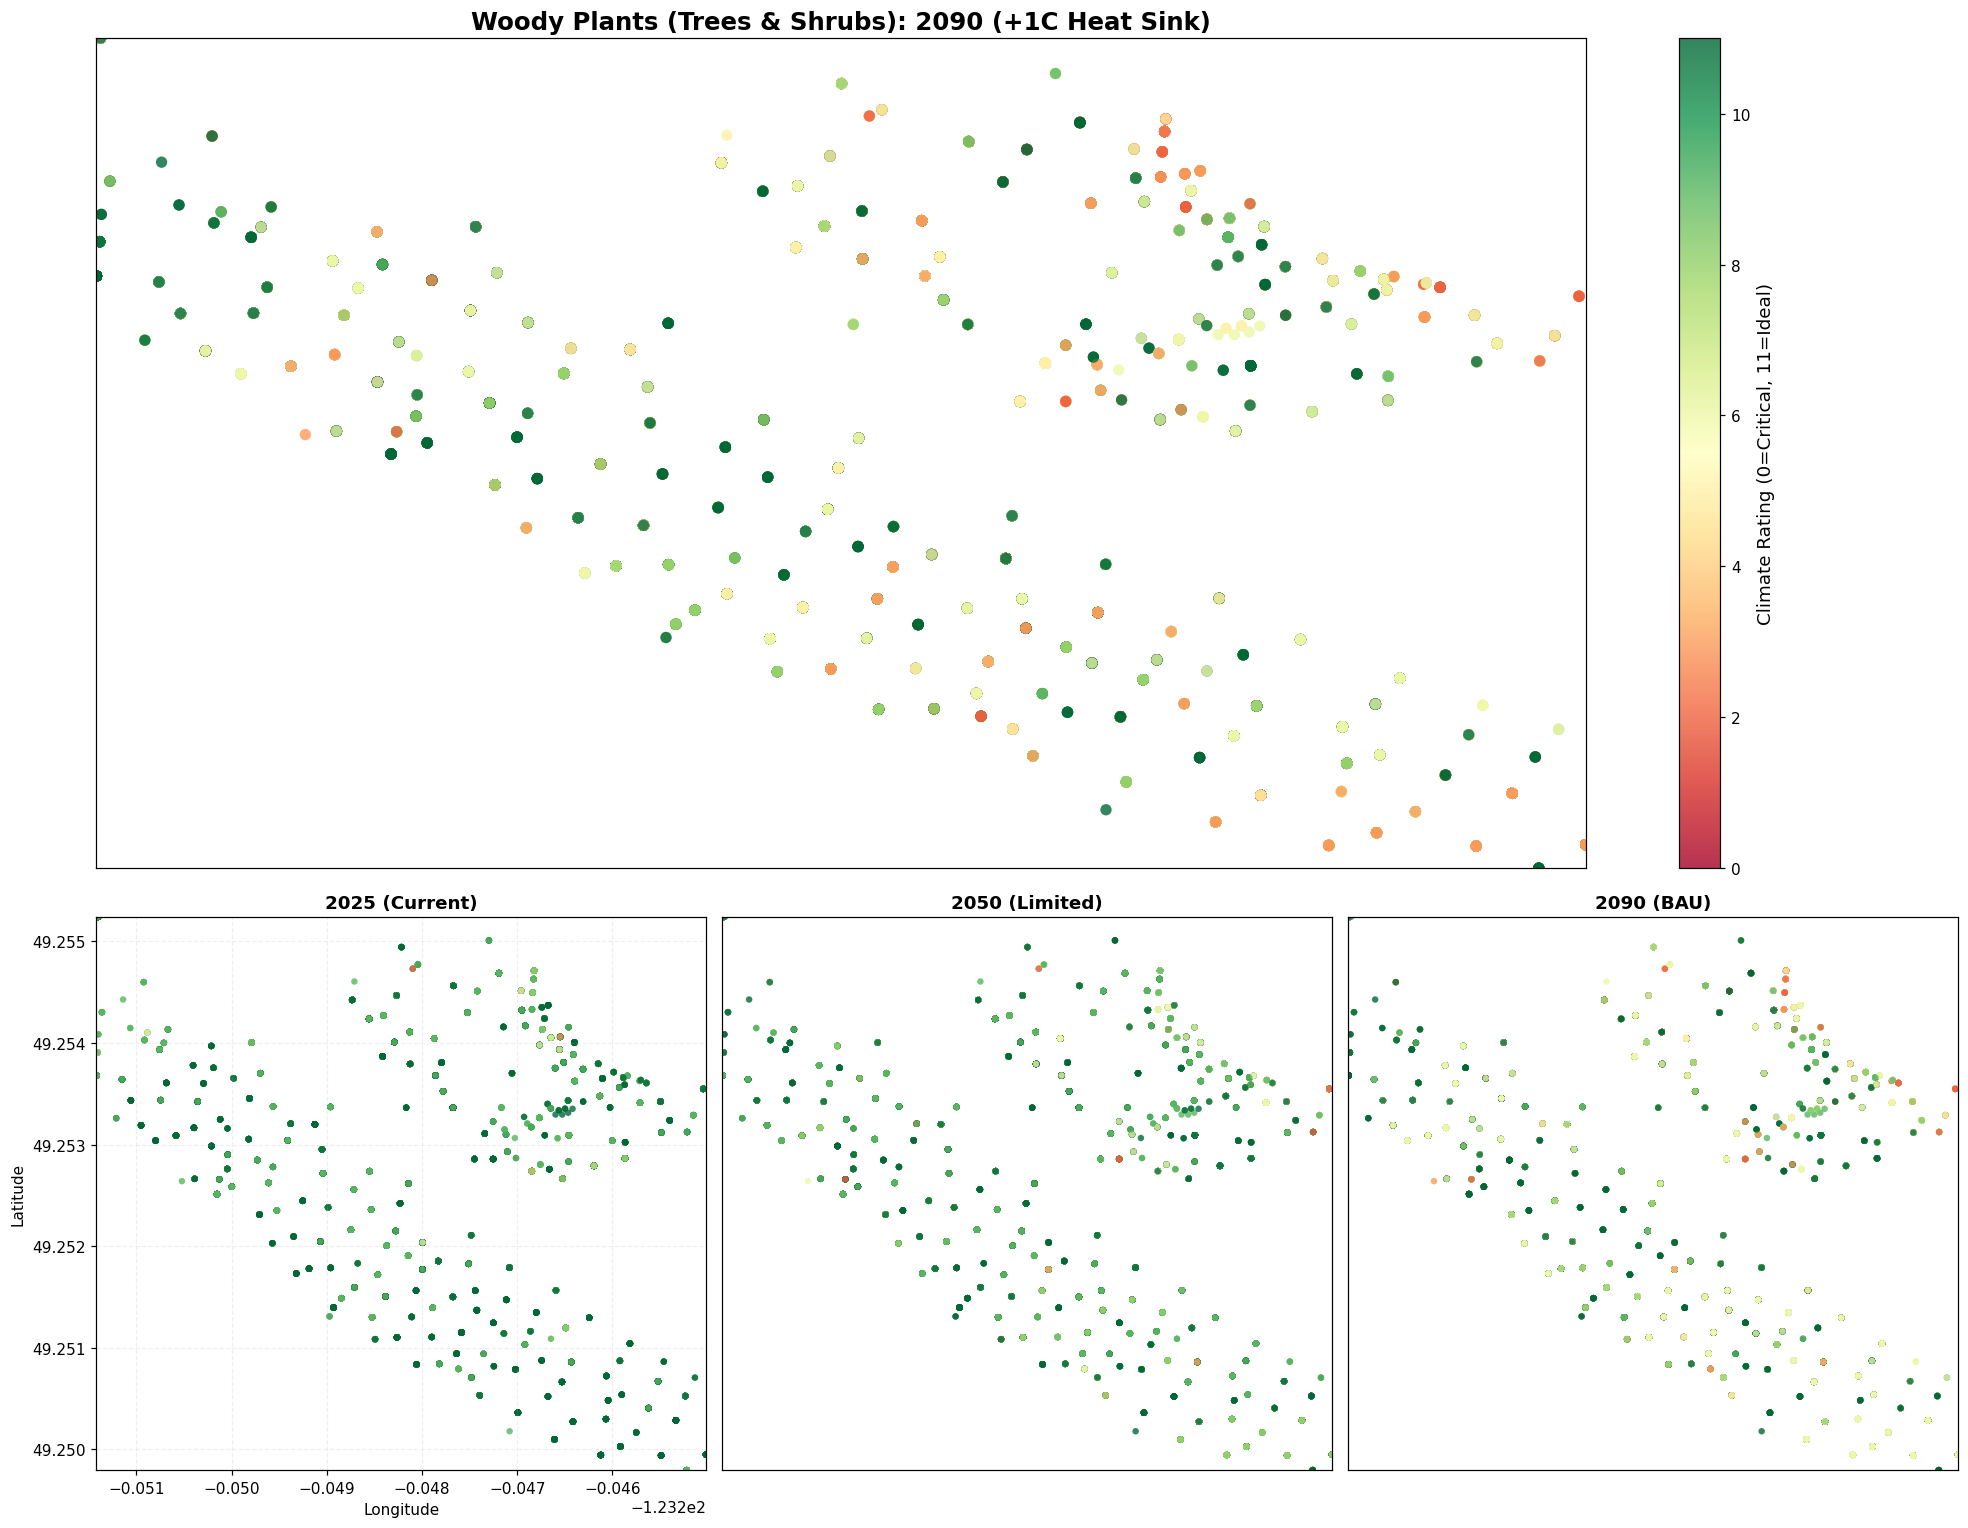

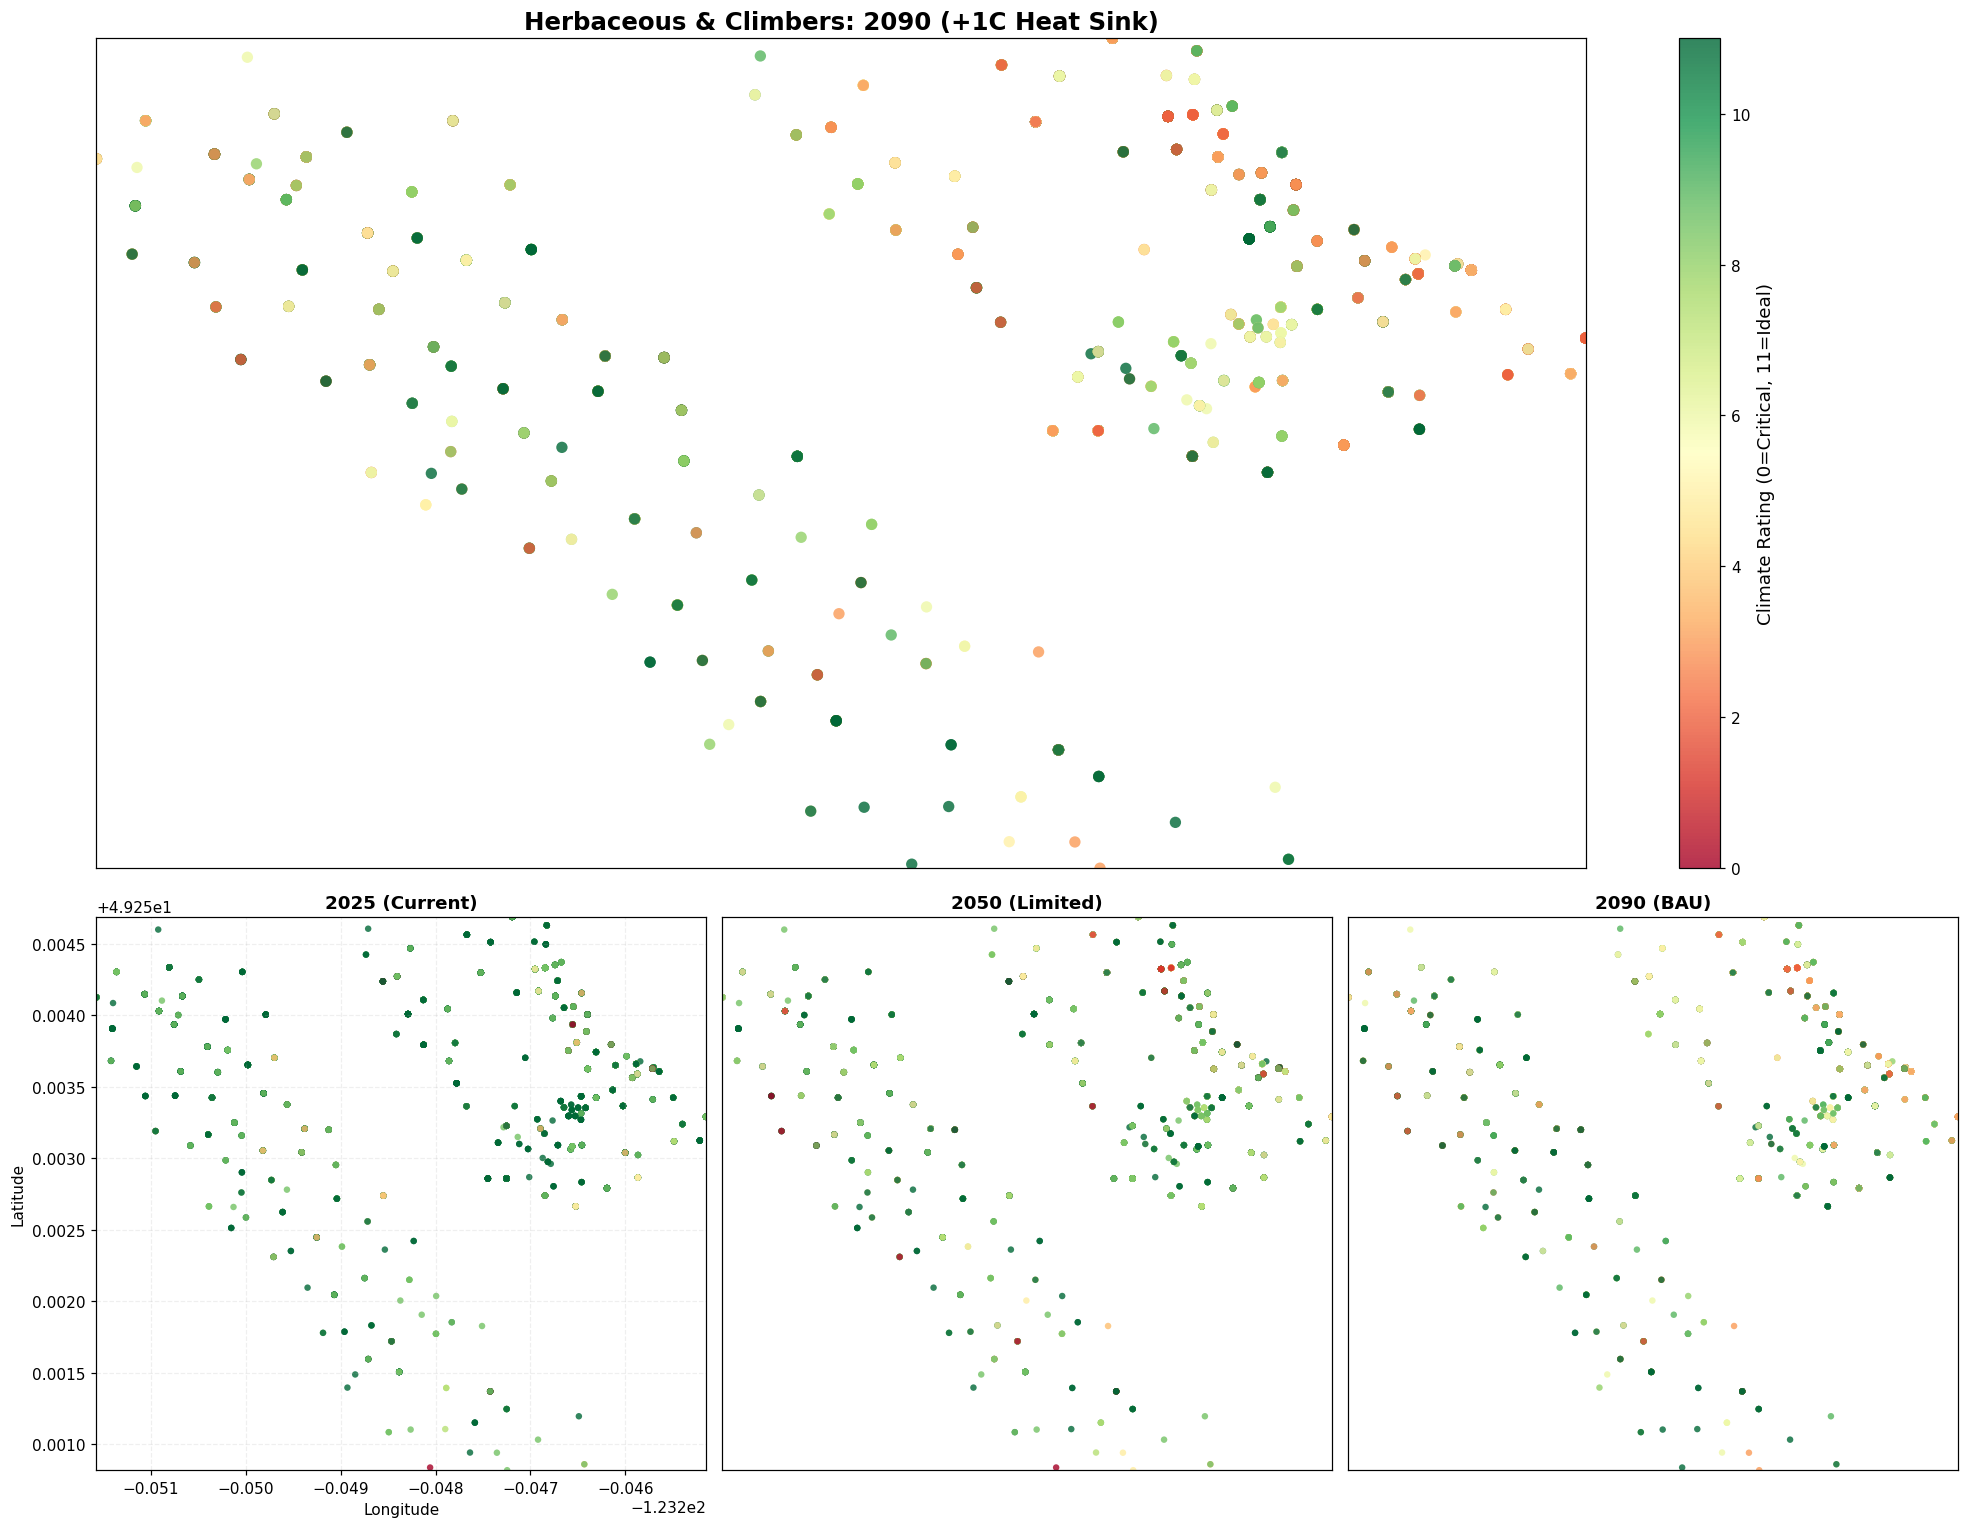

In [9]:
# Section 7

# 1. Load Data
df = pd.read_csv('../data/FullJoin3_with_climate_ratings-proofed.csv')

# 2. Rename columns (Fixes the KeyError)
rename_dict = {
    'climate_rating_current_sheet': 'rating_2025_current',
    'climate_rating_emissions_limited_2050': 'rating_2050_limited',
    'climate_rating_business_as_usual_2090': 'rating_2090_bau',
    'climate_rating_bau_plus_1degree_2090': 'rating_2090_heat_sink'
}
df = df.rename(columns=rename_dict)

# 3. Coordinate Cleaning & Standardization
# Fix historical swapping: Latitude is always the positive value (~49), 
# Longitude is always the negative value (~-123).
df['lon'] = df[['LocationCoordX', 'LocationCoordY']].min(axis=1)
df['lat'] = df[['LocationCoordX', 'LocationCoordY']].max(axis=1)

# 4. Filter Locations: Focusing on the Core Garden
# Exclude Nursery and Nitobe areas as requested
exclude_locs = ['Nursery', 'Nitobe Memorial Garden', 'Nitobe']
df_garden = df[~df['LocationName'].isin(exclude_locs)].copy()

# Remove remaining spatial artifacts east of the main garden core (-123.245)
df_garden = df_garden[df_garden['lon'] < -123.245].copy()

# Define Lifeform Subsets
woody_list = ['Tree', 'Shrub', 'Shrub or Tree']
herb_list = ['Herbaceous Perennial', 'Climber_Liana_Vine']

woody_df = df_garden[df_garden['LifeForm'].isin(woody_list)].copy()
herb_df = df_garden[df_garden['LifeForm'].isin(herb_list)].copy()

# 5. Visualization Function (Generates 1 Large + 3 Small graphs)
def create_spatial_report(data, title_prefix):
    fig = plt.figure(figsize=(18, 14))
    gs = gridspec.GridSpec(2, 3, height_ratios=[1.5, 1])

    # Configuration for the 4 scenarios
    scenarios = [
        ('rating_2090_heat_sink', f'{title_prefix}: 2090 (+1C Heat Sink)', gs[0, :], 55),
        ('rating_2025_current', '2025 (Current)', gs[1, 0], 18),
        ('rating_2050_limited', '2050 (Limited)', gs[1, 1], 18),
        ('rating_2090_bau', '2090 (BAU)', gs[1, 2], 18)
    ]

    # Calculate limits based on the actual data spread to maximize the view
    lon_min, lon_max = data['lon'].quantile(0.005), data['lon'].quantile(0.995)
    lat_min, lat_max = data['lat'].quantile(0.005), data['lat'].quantile(0.995)

    for col, subtitle, spec, s in scenarios:
        ax = plt.subplot(spec)
        valid = data.dropna(subset=['lat', 'lon', col])
        
        # Color mapping: Red (Risk) to Green (Healthy)
        scatter = ax.scatter(valid['lon'], valid['lat'], c=valid[col], 
                             cmap='RdYlGn', s=s, alpha=0.8, edgecolors='none')
        
        ax.set_title(subtitle, fontsize=16 if spec == gs[0, :] else 12, fontweight='bold')
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.grid(True, linestyle='--', alpha=0.2)
        
        if spec == gs[0, :]:
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('Climate Rating (0=Critical, 11=Ideal)', fontsize=12)
        
        if spec == gs[1, 0]:
            ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        else:
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# Generate the Two Comprehensive Map Sets
create_spatial_report(woody_df, "Woody Plants (Trees & Shrubs)")
create_spatial_report(herb_df, "Herbaceous & Climbers")

## 8. Appendix

In [10]:
# Section 8: Actionable Curatorial Risk List (CSV Export)

# 1. Filter for core garden areas and the "Danger Zone"
# We exclude Nursery/Nitobe as they represent holding areas or distinct collections
exclude_locs = ['Nursery', 'Nitobe Memorial Garden', 'Nitobe']
df_garden_only = df[~df['LocationName'].isin(exclude_locs)].copy()

# 2. Identify high-risk accessions (Rating 0-3 in 2090 Heat Sink)
curatorial_risk_list = df_garden_only[df_garden_only['rating_2090_heat_sink'] <= 3].copy()

# 3. Select columns useful for curators in the field
curatorial_cols = [
    'AccNoFull', 'ItemAccNoFull', 'Family', 'Genus', 'GenusSpecies', 
    'LifeForm', 'LocationName', 'ItemLocationCode', 
    'rating_2090_heat_sink', 'rating_2025_current'
]

# 4. Sort by Location and Family for logical field-checking
risk_export = curatorial_risk_list[curatorial_cols].sort_values(['LocationName', 'Family'])

# 5. Export to CSV
output_filename = '../outputs/UBCBG_2090_Risk_List_Curators.csv'
risk_export.to_csv(output_filename, index=False)

print(f"Exported {len(risk_export)} high-risk accessions to {output_filename}.")

Exported 2766 high-risk accessions to ../outputs/UBCBG_2090_Risk_List_Curators.csv.
